# **Load Library Yang Akan digunakan**

In [1]:
import pandas as pd
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.utils import resample
from scipy.stats import iqr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# **Load Dataset Dari Kaggle ([Dataset Link](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data))**

## **Deskripsi Kolom**
**Column-Type-Description**
1. Student_ID-Integer-Unique numeric identifier for each student (100001–150000)

2. Major_Category-Categorical-Student's field of study — STEM, Business, Humanities, Medical, Arts
3. Year_of_Study-Categorical-Academic standing — Freshman, Sophomore, Junior, Senior, Graduate
4. Pre_Semester_GPA-Float-GPA at the start of the semester (range: ~1.18 – 4.00)
5. Post_Semester_GPA-Float-GPA at the end of the semester (range: ~1.00 – 4.00) — primary outcome variable

6. Weekly_GenAI_Hours-Float-Average hours per week spent using Generative AI tools (0 – 40 hrs)
7. Primary_Use_Case-Categorical-Main purpose for which the student uses AI — Copywriting/Drafting, Summarizing_Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation
8. Prompt_Engineering_Skill-Categorical-Self-assessed proficiency in crafting effective prompts — Beginner, Intermediate, Advanced
9. Tool_Diversity-Integer-Number of distinct AI tools used (1–5)
10. Paid_Subscription-Boolean-Whether the student has a paid AI subscription (True / False)

11. Traditional_Study_Hours-Float-Weekly hours devoted to traditional (non-AI) study methods (1 – ~36 hrs)
12. Perceived_AI_Dependency-Integer-Student's self-rated dependency on AI tools, on a scale of 1 (low) to 10 (high)

13. Institutional_Policy-Categorical-The institution's official stance on AI usage — Allowed_With_Citation, Strictly_Ban, Actively_Encouraged

14. Anxiety_Level_During_Exams-Integer-Self-reported exam anxiety score from 1 (minimal) to 10 (severe)
15. Skill_Retention_Score-Float-Score (0–100) measuring how well students retained learned skills post-semester
16. Burnout_Risk_Level-Categorical-Assessed burnout risk — Low, Medium, High

## **Target Variable**
**Analisis-Kolom**
*   Regression-Post_Semester_GPA, Skill_Retention_Score
*   Classification-Burnout_Risk_Level
*   Analysis-Perceived_AI_Dependency, Anxiety_Level_During_Exams

In [2]:
# Download latest version
path = kagglehub.dataset_download("laveshjadon/ai-impact-on-students")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-students' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-students


## **Cek Nama File Di Folder**

In [3]:
for file in os.listdir(path):
    print(file)

ai_student_impact_dataset (1).csv


In [4]:
data = pd.read_csv(os.path.join(path, "ai_student_impact_dataset (1).csv"))

## **5 Kolom Teratas dan Terbawah**

In [5]:
data.head(5)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [6]:
data.tail(5)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


# **Simple EDA Untuk Penentuan Metode Pre-Processing**

## **Cek Informasi Dataset**

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [8]:
data.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


Dikarenakan Student_ID merupakan identifier data, maka kolom ini akan dihapus untuk mempermudah analisis

In [9]:
data.drop('Student_ID', axis=1, inplace=True)
data.head(5)

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [10]:
def cek_nan(data):
  """
  Function yang digunakan untuk memeriksa nilai nan dari data
  input   : data
  output  : nan_info (DataFrame)
  return  : nan_info (DataFrame)
  """
  nan_info = pd.DataFrame(data.isna().sum().sort_values(ascending=False), columns=['Jumlah Nilai Missing'])

  if nan_info['Jumlah Nilai Missing'].sum() == 0:
    print("Tidak ada nilai missing")
    return None
  else:
    nan_info['Persentase Nilai Missing (%)'] = ((nan_info['Jumlah Nilai Missing'] / len(data)) * 100).round(3)

    # return data dengan nilai missing, apabila ingin mereturn keseluruhan data maka ubah menjadi return nan_info
    return nan_info[nan_info['Jumlah Nilai Missing'] > 0]


def visualize_row_with_nan(data, method='all', columns=None):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung NaN berdasarkan metode yang dipilih
  input   : data, method, columns
  output  : baris_nan (DataFrame)
  """
  try:
    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      display(data[data.isna().any(axis=1)])

    elif method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna()])

    elif method == 'columns':
      if not isinstance(columns, list):
          raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
          if column not in data.columns:
              raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
      display(data[data[columns].isna().all(axis=1)])

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")


def visualize_row_with_duplicated(data):
  """
  Procedure yang digunakan untuk menvisualisasikan baris yang mengandung data duplikat
  input   : data
  output  : baris_duplikat (DataFrame)
  """
  duplicated = data.duplicated().sum()

  if duplicated > 0:
    print("Jumlah Data Duplikat :", duplicated)
    all_duplicates = data[data.duplicated(keep=False)]

    duplicate_indices = all_duplicates.groupby(list(all_duplicates.columns)).groups
    print("Pasangan Data Duplikat :")
    for group_indices in duplicate_indices.values():
      if len(group_indices) > 1:
        display(data.iloc[list(group_indices)])
        print("\n")
  else:
    print("Tidak ada data duplikat")


def get_bounds(data):
  """
  Function helper yang digunakan untuk mendapatkan batas bawah dan batas atas dari data
  input   : data
  output  : lower, upper
  return  : lower, upper
  """
  q1 = data.quantile(0.25)
  q3 = data.quantile(0.75)
  # nan_policy omit digunakan untuk ignore nilai NaN, sehingga perhitungan outlier tidak terganggu oleh nilai NaN
  IQR = iqr(data, nan_policy='omit')

  lower = q1 - 1.5 * IQR
  upper = q3 + 1.5 * IQR

  return lower, upper


def get_outlier(data, lower, upper, columns=None):
  """
  Function helper untuk mendapatkan outlier dari data
  input   : data, lower, upper, columns
  output  : outliers (DataFrame)
  return  : outliers (DataFrame)
  """
  return data[(data[columns] < lower) | (data[columns] > upper)]


def cek_outlier_iqr(data, method='all', columns=None):
  """
  Procedure untuk memeriksa outlier menggunakan metode IQR
  input   : data, method, columns
  output  : outliers (DataFrame)
  """
  try:
    if method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if method == 'all':
      for column in data.select_dtypes(include=np.number).columns:
        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column])
          print("\n")

      if outliers.empty:
        print(f"Tidak ada outlier pada data")

    elif method == 'column':
      if not isinstance(columns, str):
        raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
        raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(data[columns].dtype, np.number):
        raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")
      lower, upper = get_bounds(data[columns])
      outliers = get_outlier(data, lower, upper, columns)

      if not outliers.empty:
        print(f"Outliers pada kolom {columns}:")
        display(outliers[column])
      else:
        print(f"Tidak ada outlier pada kolom {columns}")

    elif method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in data.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(data[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")

        lower, upper = get_bounds(data[column])
        outliers = get_outlier(data, lower, upper, column)

        if not outliers.empty:
          print(f"Outliers pada kolom {column}:")
          display(outliers[column])
          print("\n")
        else:
          print(f"Tidak ada outlier pada kolom {column}")

  except (TypeError, KeyError) as e:
    print(f"Kesalahan dalam memproses data: {e}")


def filter_outlier_method(data, lower, upper, method='capping', column=None):
  """
  Function helper untuk menfilter data berdasarkan batas bawah dan batas atas
  input   : data, lower, upper, method, columns
  output  : filtered_data (DataFrame)
  return  : filtered_data (DataFrame)
  """
  if method == "nan":  # ubah outlier → NaN
    data.loc[(data[column] < lower) | (data[column] > upper), column] = np.nan
  elif method == "drop":  # hapus baris dengan outlier
    data = data[(data[column] >= lower) & (data[column] <= upper)]
  elif method == "capping":
    data.loc[data[column] < lower, column] = lower
    data.loc[data[column] > upper, column] = upper

  return data


def filter_outliers_iqr(data, filter_method="capping", column_method="all", columns=None):
  """
  Procedure untuk menfilter outlier menggunakan metode IQR
  input   : data, filter_method, column_method, columns
  output  : filtered data (DataFrame)
  return  : filtered data (DataFrame)
  """
  try:
    if filter_method not in ['nan', 'drop', 'capping']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'nan', 'drop', 'capping'.")
    if column_method not in ['all', 'column', 'columns']:
      raise ValueError("Metode tidak valid. Pilih salah satu dari 'all', 'column', 'columns'.")

    if column_method == 'all':
      for column in data.select_dtypes(include=np.number).columns:
        lower, upper = get_bounds(data[column])
        data = filter_outlier_method(data, lower, upper, filter_method, column)

    if column_method == 'column':
      if not isinstance(columns, str):
          raise TypeError("Untuk metode 'column', argumen 'columns' harus berupa String.")
      if columns not in data.columns:
          raise KeyError(f"Kolom '{columns}' tidak ditemukan dalam DataFrame.")
      if not np.issubdtype(data[columns].dtype, np.number):
          raise TypeError(f"Kolom '{columns}' bukan tipe numerik.")

      lower, upper = get_bounds(data[columns])
      data = filter_outlier_method(data, lower, upper, filter_method, column)

    if column_method == 'columns':
      if not isinstance(columns, list):
        raise TypeError("Untuk metode 'columns', argumen 'columns' harus berupa list.")
      for column in columns:
        if column not in data.columns:
          raise KeyError(f"Kolom '{column}' tidak ditemukan dalam DataFrame.")
        if not np.issubdtype(data[column].dtype, np.number):
          raise TypeError(f"Kolom '{column}' bukan tipe numerik.")

        lower, upper = get_bounds(data[column])
        data = filter_outlier_method(data, lower, upper, filter_method, column)

  except (ValueError) as e:
    print(f"Kesalahan dalam memproses data: {e}")
  return data

## **Cek Nilai NaN**

In [11]:
cek_nan(data)

Tidak ada nilai missing


## **Cek Nilai Duplikat**

In [12]:
visualize_row_with_duplicated(data)

Tidak ada data duplikat


## **Cek Outlier**

In [13]:
cek_outlier_iqr(data)

Outliers pada kolom Pre_Semester_GPA:


,Pre_Semester_GPA
31,1.449
170,1.737
198,1.691
443,1.666
508,1.793
...,...
49078,1.761
49388,1.766
49426,1.666
49580,1.467




Outliers pada kolom Weekly_GenAI_Hours:


,Weekly_GenAI_Hours
6,31.41
24,28.72
89,34.00
98,28.71
100,25.83
...,...
49877,35.33
49908,36.73
49921,29.82
49937,40.00




Outliers pada kolom Traditional_Study_Hours:


...

,Perceived_AI_Dependency
124,10
556,10
650,10
656,10
1340,10
...,...
49064,10
49338,10
49480,10
49828,10




Outliers pada kolom Post_Semester_GPA:


,Post_Semester_GPA
31,1.342
198,1.860
226,1.866
323,1.816
443,1.857
...,...
49523,1.923
49580,1.874
49662,1.715
49698,1.925




Outliers pada kolom Skill_Retention_Score:


,Skill_Retention_Score
492,38.81
650,39.14
705,37.21
724,17.22
1110,35.17
...,...
49686,35.05
49698,35.86
49820,35.67
49828,33.60


## **Visualisasi Persebaran Data Untuk Melihat Data Yang Diduga Outlier**

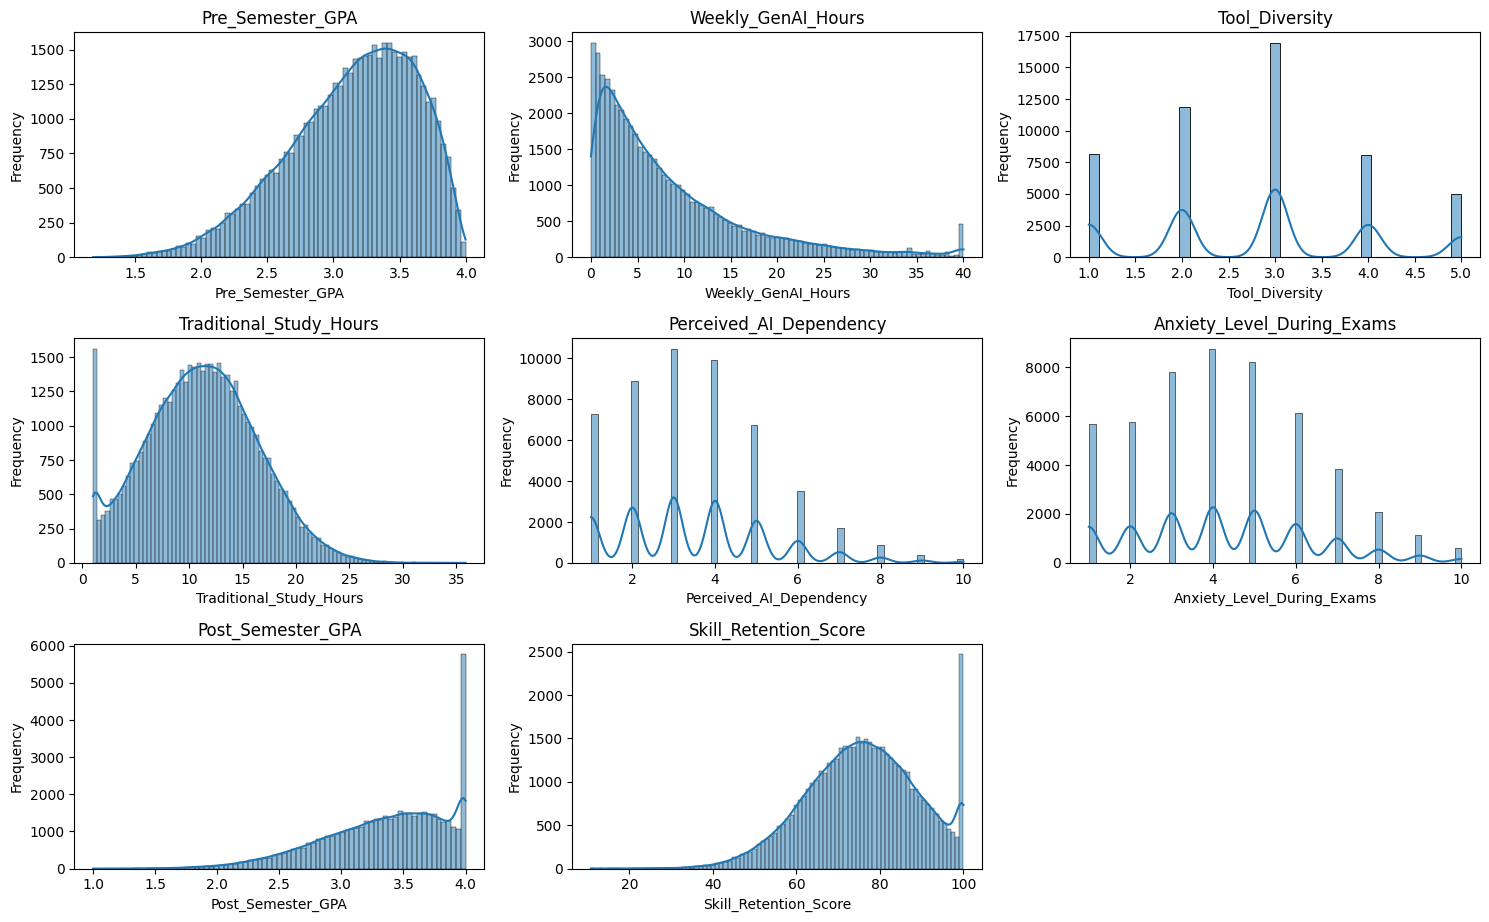

In [14]:
col = 3
row = math.ceil(data.shape[1] / col)

plt.figure(figsize=(15, 15))

for i, column in enumerate(data.select_dtypes(include=np.number).columns, 1):
  plt.subplot(row, col, i)
  sns.histplot(data[column], kde=True)
  plt.title(column)
  plt.xlabel(column)
  plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

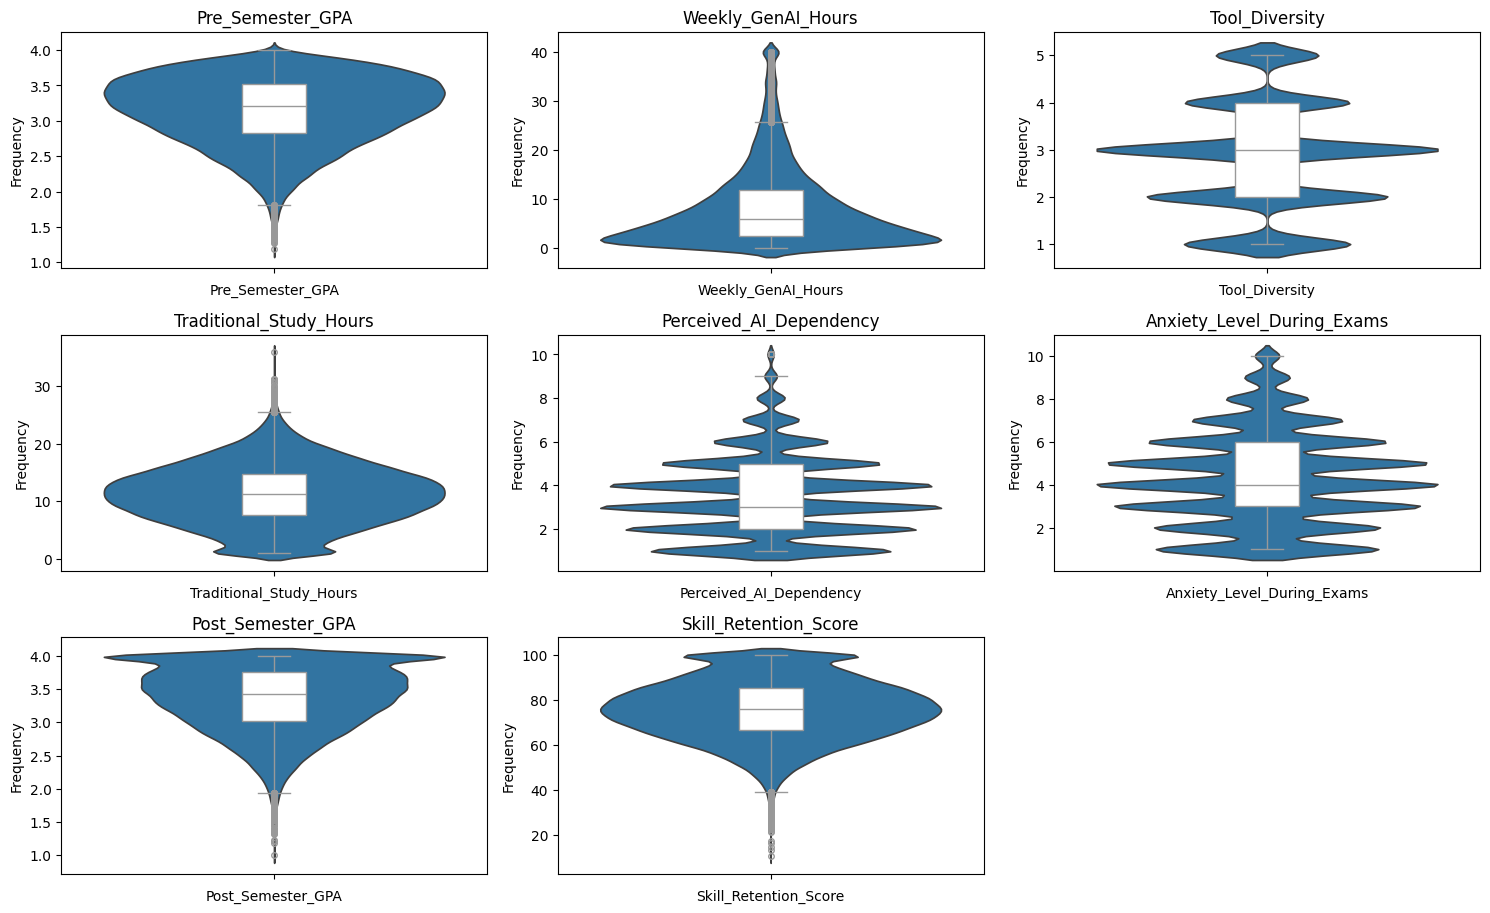

In [15]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(data.select_dtypes(include=np.number).columns, 1):
  plt.subplot(row, col, i)
  sns.violinplot(data[column], inner=None)
  sns.boxplot(data[column], width=0.15, color='white', linewidth=1, fliersize=4)
  plt.title(column)
  plt.xlabel(column)
  plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Walaupun ditemukan adanya outlier melalui pemeriksaan IQR, ditemukan bahwa nilai tersebut masih termasuk dalam batas normal didalam range yang ditentukan, sehingga nilai yang diduga outlier tersebut tetap akan dipertahankan.

# **EDA Lanjutan Untuk Analisis Mendalam**

## **Distribusi Burnout Level**

/tmp/ipykernel_69320/1069747430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='viridis')


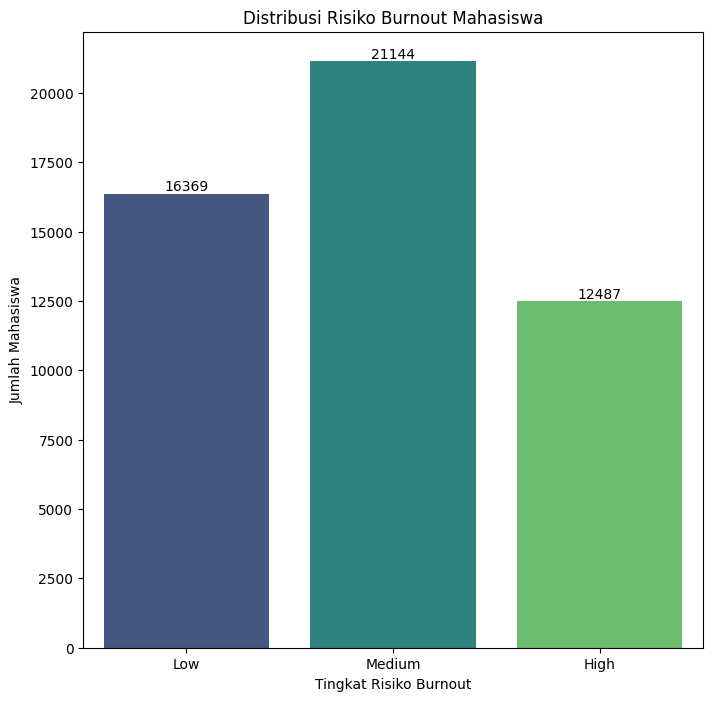

In [16]:
plt.figure(figsize=(8, 8))
ax = sns.countplot(data=data, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Distribusi Risiko Burnout Mahasiswa')
plt.xlabel('Tingkat Risiko Burnout')
plt.ylabel('Jumlah Mahasiswa')
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.bar_label(ax.containers[2])
plt.show()

Dari sisi tingkat risiko burnout, ditemukan bahwa tingkat burnout tertinggi terdapat pada tingkat medium. Untuk mengetahui lebih lanjut variable mana yang paling mempengaruhi tingkat burnout, akan dilakukan analisis plot per masing-masing kolom.

## **Visualisasi Tren dengan Point Plot**

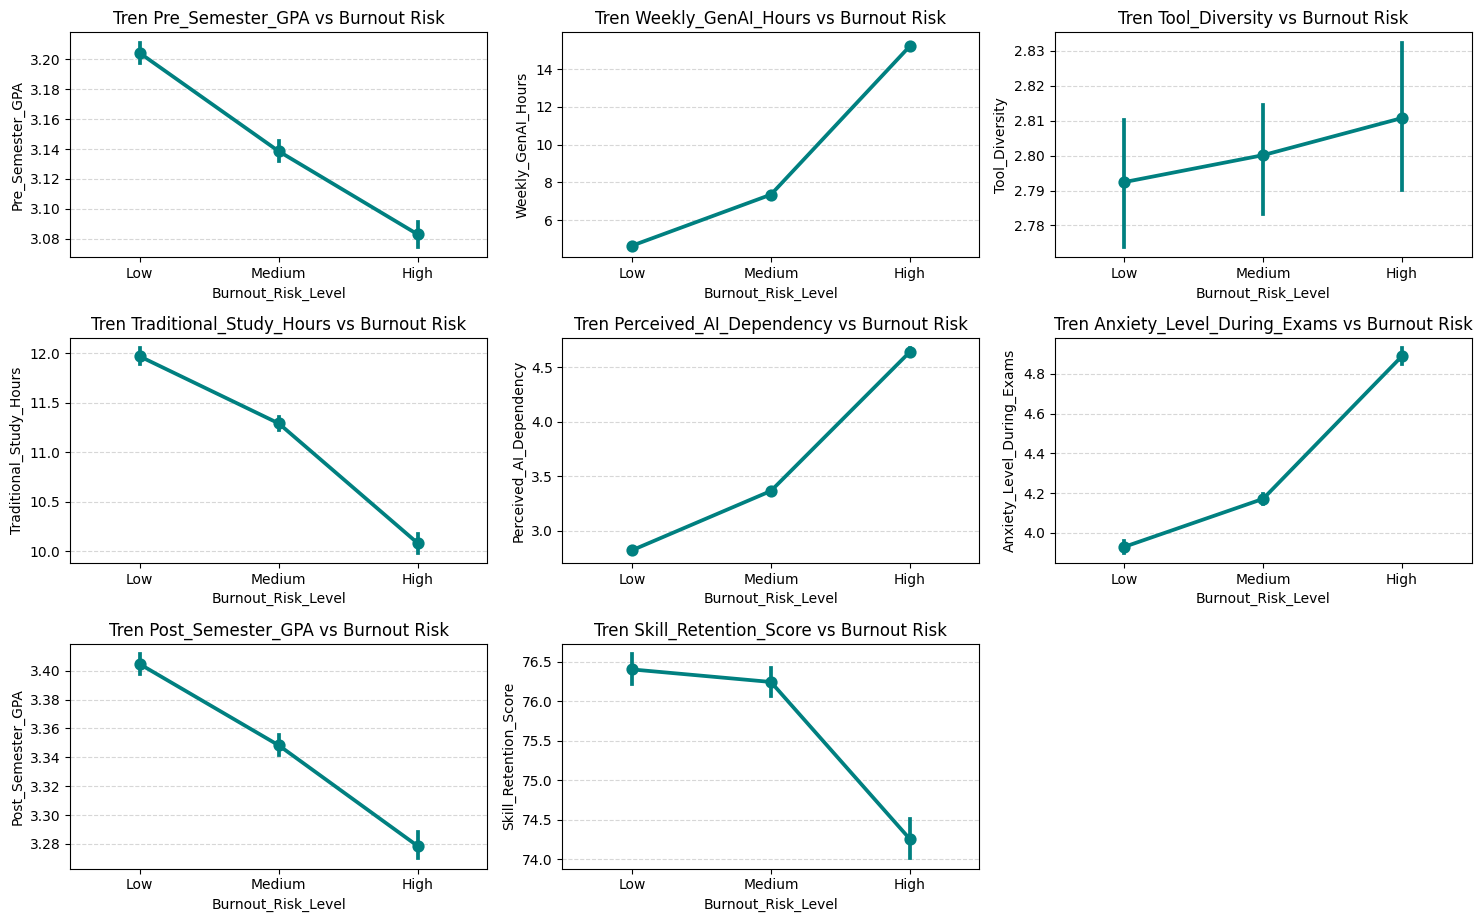

In [17]:
col = 3
row = math.ceil(data.shape[1] / col)

plt.figure(figsize=(15, 15))

for i, column in enumerate(data.select_dtypes(include=np.number).columns, 1):
  plt.subplot(row, col, i)
  sns.pointplot(data=data, x='Burnout_Risk_Level', y=column, order=['Low', 'Medium', 'High'], color='teal')
  plt.title(f'Tren {column} vs Burnout Risk')
  plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi tren tersebut, ditemukan beberapa informasi menarik dari data.
1. Tingkatan sering menggunakan AI per minggu, semakin tinggi tingkat anxiety ketika ujian dan semakin ketergantungan seseorang terhadap AI, maka semakin tinggi pula tingkatan burnout nya.
2. Semakin tinggi jumlah jam belajar tradisional seseorang, maka semakin rendah tingkatan burnout nya.
3. Semakin banyak jumlah tools AI yang digunakan, maka semakin tinggi pula tingkatan burnout nya.
4. Semakin tinggi nilai keterampilan pembelajaran siswa sampai akhir semester, maka tingkatan burnout nya menjadi semakin rendah.

# **Processing Data**

## **Cek Informasi Data Yang Akan Dilakukan Encoding**

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       500

In [19]:
data_object_boolean = data.select_dtypes(include=['object', 'bool'])
data_object_boolean.head(5)

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Paid_Subscription,Institutional_Policy,Burnout_Risk_Level
0,Humanities,Senior,Copywriting/Drafting,Beginner,True,Allowed_With_Citation,High
1,Medical,Junior,Ideation,Advanced,False,Allowed_With_Citation,Low
2,Business,Freshman,Summarizing_Reading,Beginner,False,Strict_Ban,Medium
3,Business,Senior,Copywriting/Drafting,Intermediate,False,Allowed_With_Citation,Medium
4,STEM,Sophomore,Debugging/Troubleshooting,Advanced,False,Allowed_With_Citation,Medium


## **Encoding Fitur Kategorikal**

In [20]:
le_target = LabelEncoder()
data['Burnout_Risk_Level'] = le_target.fit_transform(data['Burnout_Risk_Level'])

In [21]:
prompt_mapping = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}

data['Prompt_Engineering_Skill'] = data['Prompt_Engineering_Skill'].map(prompt_mapping)

In [22]:
Year_of_Study_mapping = {'Freshman':1, 'Sophomore':2, 'Junior':3, 'Senior':4, 'Graduate':5}

data['Year_of_Study'] = data['Year_of_Study'].map(Year_of_Study_mapping)

In [23]:
data['Paid_Subscription'] = data['Paid_Subscription'].astype(int)

In [24]:
data = pd.get_dummies(data)

In [25]:
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

In [26]:
data.head(5)

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,Major_Category_Medical,Major_Category_STEM,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban
0,4,2.418,23.31,0,1,1,8.13,5,6,2.393,...,0,0,1,0,0,0,0,0,1,0
1,3,3.821,1.12,2,5,0,16.65,3,9,3.696,...,1,0,0,0,0,1,0,0,1,0
2,1,3.398,21.26,0,2,0,10.35,5,9,3.499,...,0,0,0,0,0,0,1,0,0,1
3,4,3.789,1.82,1,4,0,15.23,2,2,4.000,...,0,0,1,0,0,0,0,0,1,0
4,2,3.635,9.29,2,4,0,12.55,4,4,3.798,...,0,1,0,1,0,0,0,0,1,0


## **Feature Engineering**

In [27]:
data['gpa_difference'] = data['Post_Semester_GPA'] - data['Pre_Semester_GPA']
data['hours_per_week'] = data['Weekly_GenAI_Hours'] + data['Traditional_Study_Hours']

## **Analisis Korelasi Untuk Menentukan Fitur Yang Akan Digunakan**

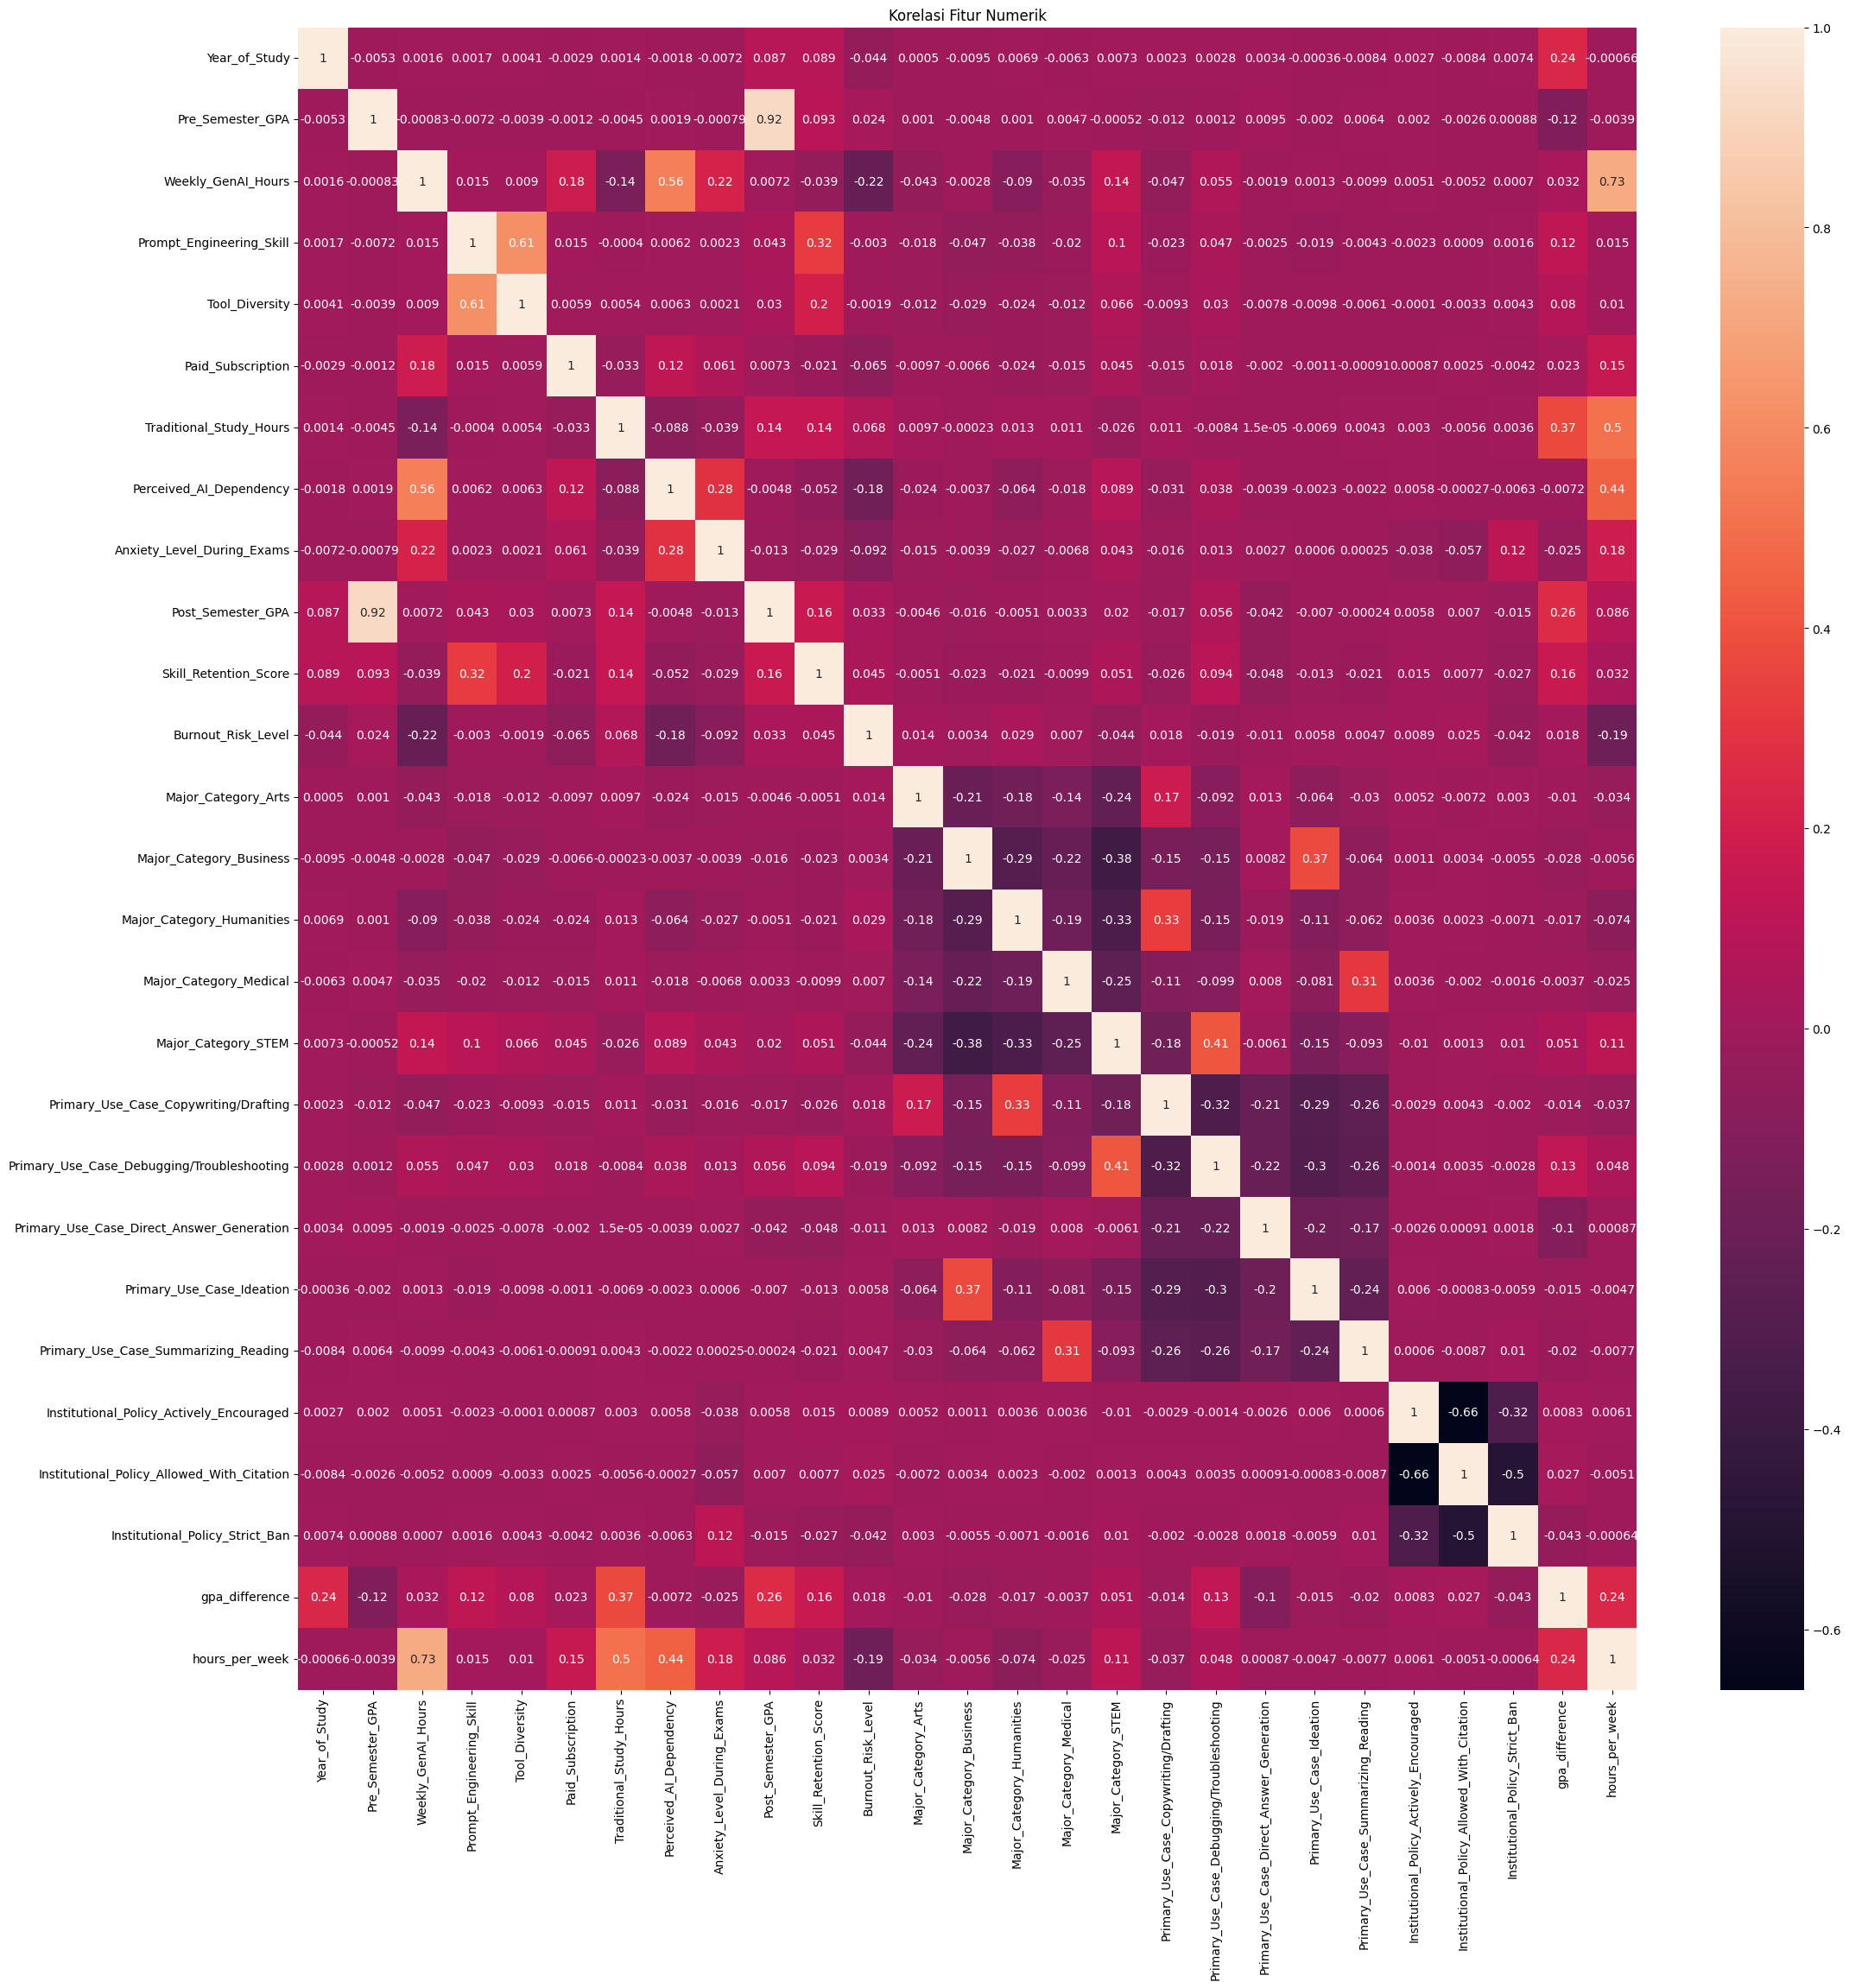

In [28]:
corr = data.corr(method='spearman')
plt.figure(figsize=(25, 25))
sns.heatmap(corr, annot=True)
plt.title('Korelasi Fitur Numerik')
plt.show()

In [29]:
corr_stacked = corr.unstack()
corr_stacked = corr_stacked[corr_stacked != 1.0]
target_corr = corr_stacked[abs(corr_stacked) > 0.8].drop_duplicates()

print("Pasangan variabel dengan korelasi > 0.8:")
print(target_corr)

Pasangan variabel dengan korelasi > 0.8:
Pre_Semester_GPA  Post_Semester_GPA    0.917233
dtype: float64


Kolom memiliki nilai korelasi yang kuat diatas 0.9 kemungkinan akan memiliki redudansi informasi. Cara penanganan nya adalah salah satu kolom yang kurang memiliki korelasi dengan target akan dihapus.

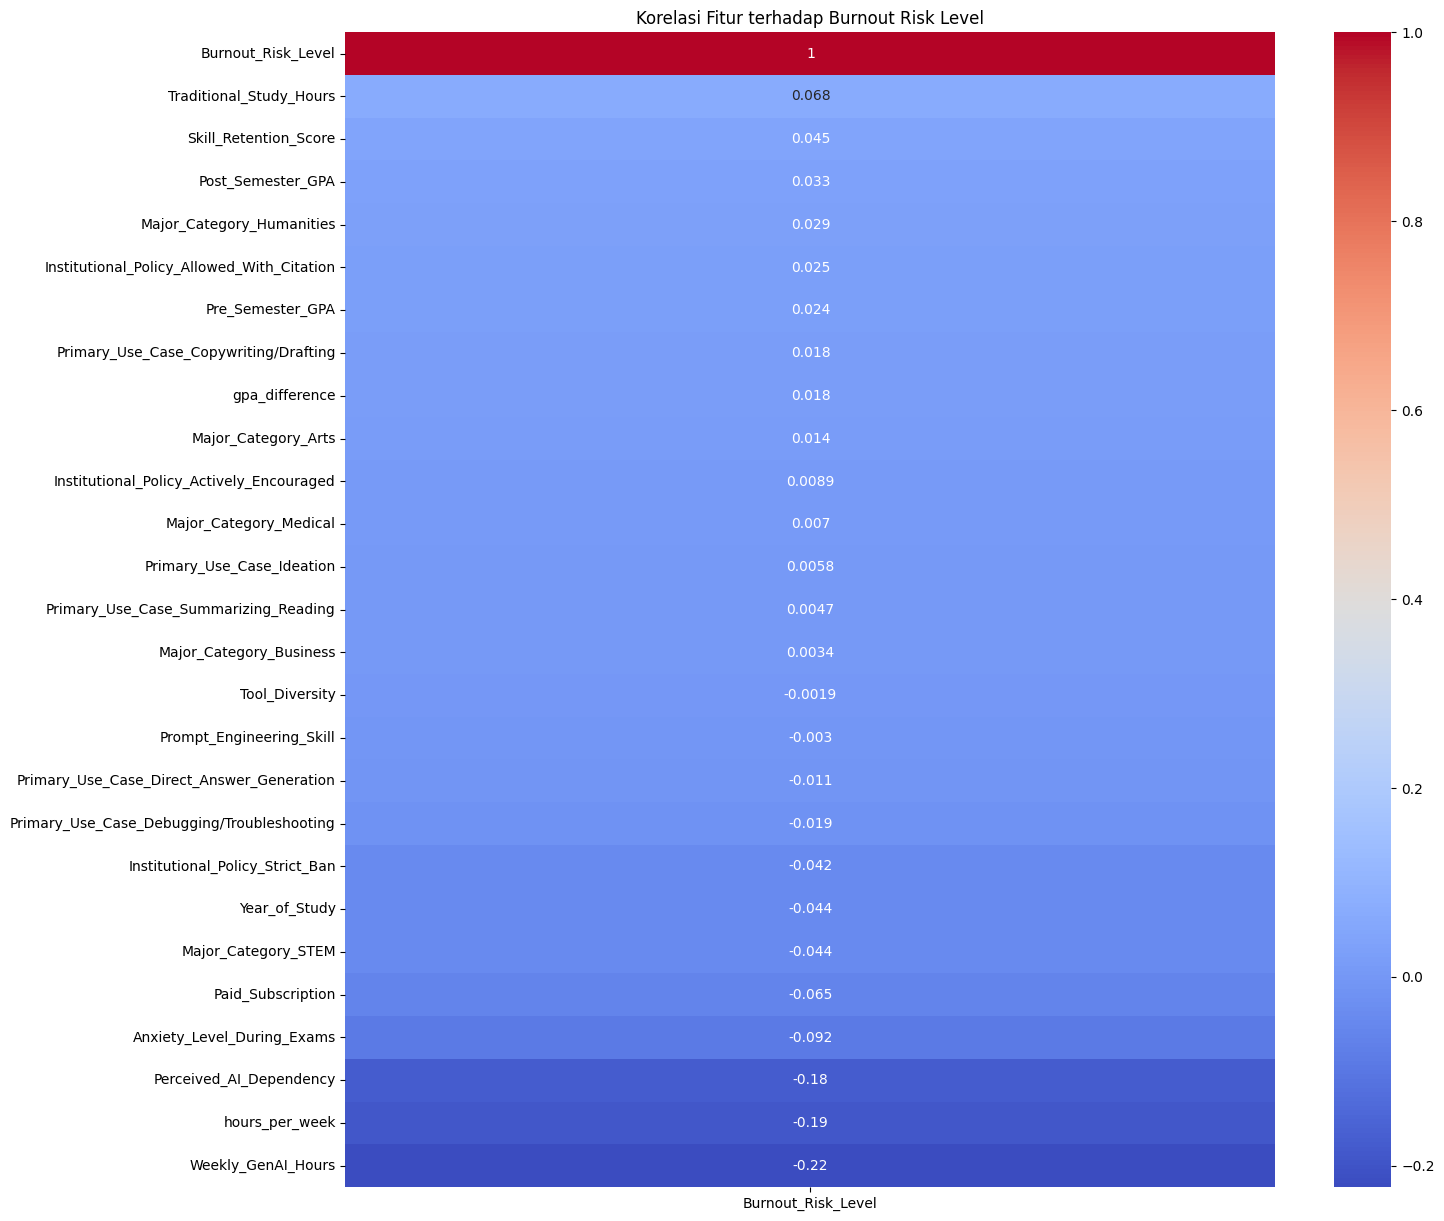

In [30]:
corr_target = data.corr(method='spearman')
corr_target = corr_target[['Burnout_Risk_Level']].sort_values(by='Burnout_Risk_Level', ascending=False)
plt.figure(figsize=(15, 15))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', cbar=True)
plt.title('Korelasi Fitur terhadap Burnout Risk Level')
plt.show()

In [31]:
data.drop(['Pre_Semester_GPA'], axis=1, inplace=True)

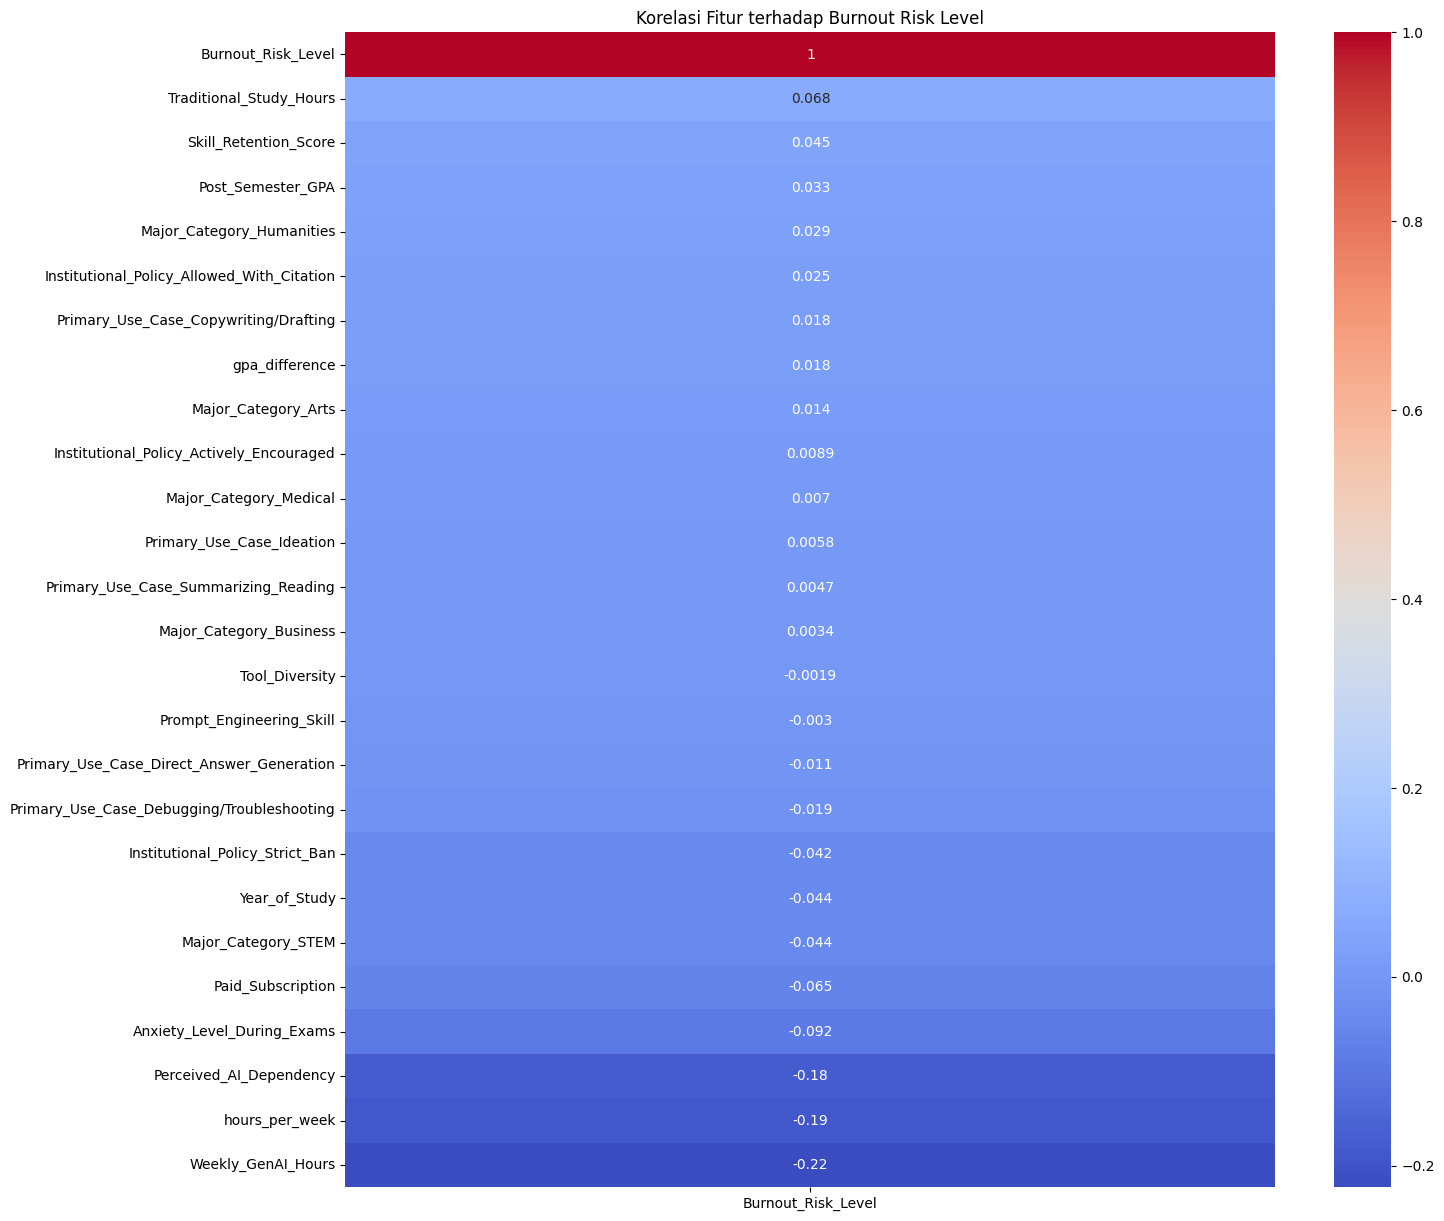

In [32]:
corr_target = data.corr(method='spearman')
corr_target = corr_target[['Burnout_Risk_Level']].sort_values(by='Burnout_Risk_Level', ascending=False)
plt.figure(figsize=(15, 15))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', cbar=True)
plt.title('Korelasi Fitur terhadap Burnout Risk Level')
plt.show()

## **Filter Kolom Yang Memiliki Korelasi Positif Dengan Target**

In [33]:
top_15_kolom_target = corr_target.head(15).index
top_15_kolom_target

Index(['Burnout_Risk_Level', 'Traditional_Study_Hours',
       'Skill_Retention_Score', 'Post_Semester_GPA',
       'Major_Category_Humanities',
       'Institutional_Policy_Allowed_With_Citation',
       'Primary_Use_Case_Copywriting/Drafting', 'gpa_difference',
       'Major_Category_Arts', 'Institutional_Policy_Actively_Encouraged',
       'Major_Category_Medical', 'Primary_Use_Case_Ideation',
       'Primary_Use_Case_Summarizing_Reading', 'Major_Category_Business',
       'Tool_Diversity'],
      dtype='object')

In [34]:
data_selected = data[top_15_kolom_target]
data_selected

,Burnout_Risk_Level,Traditional_Study_Hours,Skill_Retention_Score,Post_Semester_GPA,Major_Category_Humanities,Institutional_Policy_Allowed_With_Citation,Primary_Use_Case_Copywriting/Drafting,gpa_difference,Major_Category_Arts,Institutional_Policy_Actively_Encouraged,Major_Category_Medical,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Major_Category_Business,Tool_Diversity
0,0,8.13,86.44,2.393,1,1,1,-0.025,0,0,0,0,0,0,1
1,1,16.65,69.39,3.696,0,1,0,-0.125,0,0,1,1,0,0,5
2,2,10.35,73.93,3.499,0,0,0,0.101,0,0,0,0,1,1,2
3,2,15.23,63.58,4.000,0,1,1,0.211,0,0,0,0,0,1,4
4,2,12.55,100.00,3.798,0,1,0,0.163,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,13.36,66.16,3.584,0,1,1,0.685,0,0,0,0,0,1,2
49996,2,4.67,81.62,3.096,0,0,1,0.226,0,1,0,0,0,0,1
49997,0,3.92,97.21,3.605,0,1,0,0.428,0,0,0,0,1,1,5
49998,2,7.10,84.12,3.527,0,1,0,0.129,0,0,0,0,0,1,5


## **Resampling Data**

In [35]:
# 0: High, 1: Low, 2: Medium
data_selected_0 = data_selected[data_selected['Burnout_Risk_Level'] == 0]
data_selected_1 = data_selected[data_selected['Burnout_Risk_Level'] == 1]
data_selected_2 = data_selected[data_selected['Burnout_Risk_Level'] == 2]

n_samples = len(data_selected_2)

data_selected_0_upsampling = resample(data_selected_0, replace=True, n_samples=n_samples, random_state=42)
data_selected_1_upsampling = resample(data_selected_1, replace=True, n_samples=n_samples, random_state=42)

data_selected_balanced = pd.concat([data_selected_2, data_selected_1_upsampling, data_selected_0_upsampling])

Upsampling data agar memiliki jumlah target yang serupa, sehingga tidak terjadi prediksi kelas dominan.

/tmp/ipykernel_69320/925551886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data_selected_balanced, x='Burnout_Risk_Level', palette='viridis')


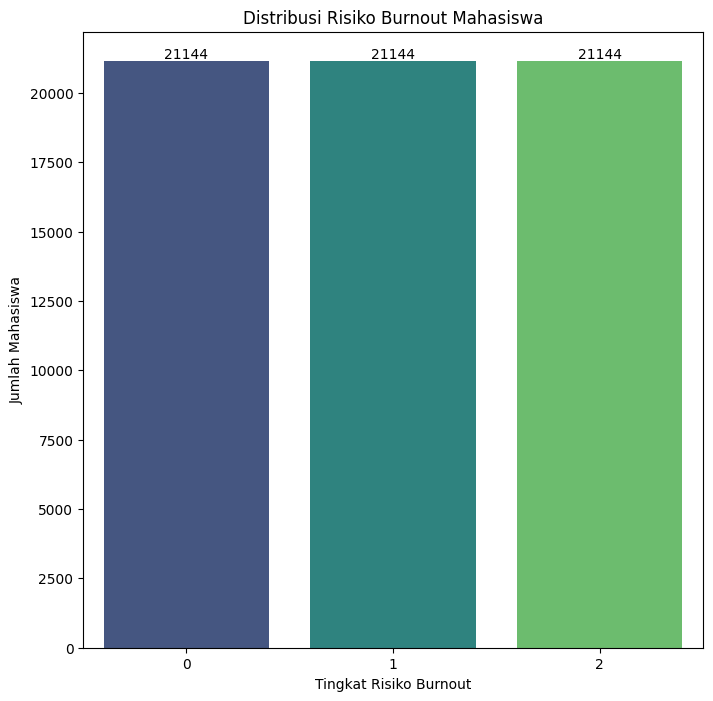

In [36]:
plt.figure(figsize=(8, 8))
ax = sns.countplot(data=data_selected_balanced, x='Burnout_Risk_Level', palette='viridis')
plt.title('Distribusi Risiko Burnout Mahasiswa')
plt.xlabel('Tingkat Risiko Burnout')
plt.ylabel('Jumlah Mahasiswa')
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.bar_label(ax.containers[2])
plt.show()

## **Splitting Data**

In [37]:
X = data_selected_balanced.drop('Burnout_Risk_Level', axis=1)
y = data_selected_balanced['Burnout_Risk_Level']

In [38]:
X.head(5)

,Traditional_Study_Hours,Skill_Retention_Score,Post_Semester_GPA,Major_Category_Humanities,Institutional_Policy_Allowed_With_Citation,Primary_Use_Case_Copywriting/Drafting,gpa_difference,Major_Category_Arts,Institutional_Policy_Actively_Encouraged,Major_Category_Medical,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Major_Category_Business,Tool_Diversity
2,10.35,73.93,3.499,0,0,0,0.101,0,0,0,0,1,1,2
3,15.23,63.58,4.000,0,1,1,0.211,0,0,0,0,0,1,4
4,12.55,100.00,3.798,0,1,0,0.163,0,0,0,0,0,0,4
6,13.11,67.97,4.000,0,1,0,0.378,0,0,0,0,1,0,5
7,18.45,85.09,2.965,0,0,1,0.219,1,1,0,0,0,0,3


In [39]:
y.head(5)

,Burnout_Risk_Level
2,2
3,2
4,2
6,2
7,2


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Standarisasi Data**

In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Modelling**

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print(f"Akurasi Random Forest: {accuracy_score(y_test, rf_pred):.4f}")

xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print(f"Akurasi XGBoost: {accuracy_score(y_test, xgb_pred):.4f}")

Akurasi Random Forest: 0.7075
Akurasi XGBoost: 0.5177


# **Evaluasi Model**

=== Laporan Evaluasi XGBoost ===
Akurasi Akhir: 0.5177

              precision    recall  f1-score   support

        High       0.56      0.62      0.59      4194
         Low       0.53      0.56      0.55      4305
      Medium       0.45      0.37      0.40      4188

    accuracy                           0.52     12687
   macro avg       0.51      0.52      0.51     12687
weighted avg       0.51      0.52      0.51     12687



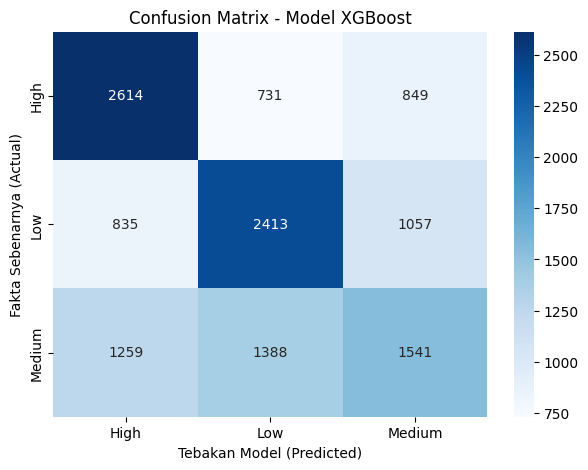

In [43]:
print("=== Laporan Evaluasi XGBoost ===")
print(f"Akurasi Akhir: {accuracy_score(y_test, xgb_pred):.4f}\n")
print(classification_report(y_test, xgb_pred, target_names=le_target.classes_))

# Visualisasi Confusion Matrix untuk model
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Model XGBoost')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Fakta Sebenarnya (Actual)')
plt.show()

=== Laporan Evaluasi Random Forest ===
Akurasi Akhir: 0.7075

              precision    recall  f1-score   support

        High       0.76      0.80      0.78      4194
         Low       0.74      0.73      0.73      4305
      Medium       0.61      0.59      0.60      4188

    accuracy                           0.71     12687
   macro avg       0.71      0.71      0.71     12687
weighted avg       0.71      0.71      0.71     12687



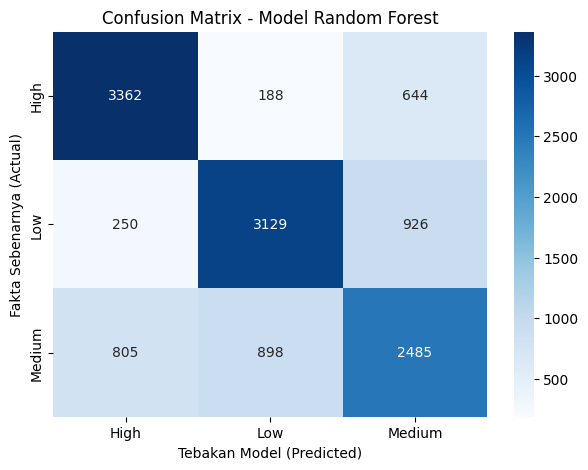

In [44]:
print("=== Laporan Evaluasi Random Forest ===")
print(f"Akurasi Akhir: {accuracy_score(y_test, rf_pred):.4f}\n")
print(classification_report(y_test, rf_pred, target_names=le_target.classes_))

# Visualisasi Confusion Matrix untuk model
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Model Random Forest')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Fakta Sebenarnya (Actual)')
plt.show()

# **Hyperparameter Tuning**

In [45]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=0
)

grid_search.fit(X_train, y_train)
print(f"Parameter Terbaik Ditemukan: {grid_search.best_params_}")

best_xgb_model = grid_search.best_estimator_
best_xgb_pred = best_xgb_model.predict(X_test)

Parameter Terbaik Ditemukan: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [46]:
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=0
)

grid_search.fit(X_train, y_train)
print(f"Parameter Terbaik Ditemukan: {grid_search.best_params_}")

best_rf_model = grid_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)

Parameter Terbaik Ditemukan: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}


# **Evaluasi Model Tuning**

=== Laporan Evaluasi Final (XGBoost Tuned) ===
Akurasi Akhir: 0.6014

              precision    recall  f1-score   support

        High       0.64      0.71      0.67      4194
         Low       0.61      0.64      0.63      4305
      Medium       0.53      0.45      0.49      4188

    accuracy                           0.60     12687
   macro avg       0.60      0.60      0.60     12687
weighted avg       0.60      0.60      0.60     12687



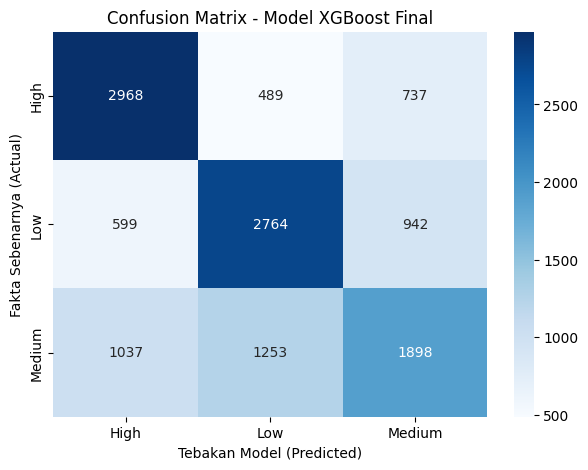

In [47]:
print("=== Laporan Evaluasi Final (XGBoost Tuned) ===")
print(f"Akurasi Akhir: {accuracy_score(y_test, best_xgb_pred):.4f}\n")
print(classification_report(y_test, best_xgb_pred, target_names=le_target.classes_))

# Visualisasi Confusion Matrix untuk model final
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, best_xgb_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Model XGBoost Final')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Fakta Sebenarnya (Actual)')
plt.show()

=== Laporan Evaluasi Final (Random Forest Tuned) ===
Akurasi Akhir: 0.4254

              precision    recall  f1-score   support

        High       0.44      0.57      0.49      4194
         Low       0.44      0.53      0.48      4305
      Medium       0.36      0.17      0.23      4188

    accuracy                           0.43     12687
   macro avg       0.41      0.42      0.40     12687
weighted avg       0.41      0.43      0.40     12687



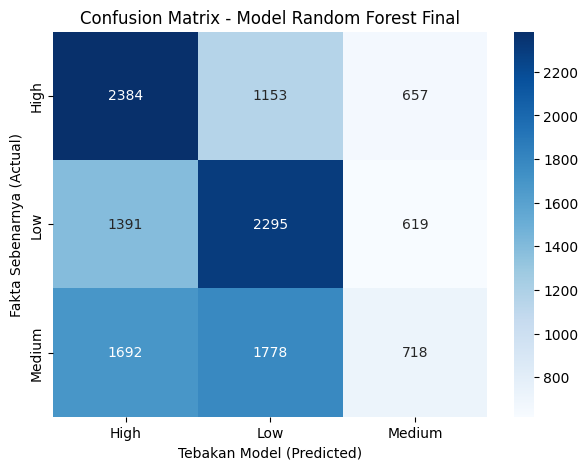

In [48]:
print("=== Laporan Evaluasi Final (Random Forest Tuned) ===")
print(f"Akurasi Akhir: {accuracy_score(y_test, best_rf_pred):.4f}\n")
print(classification_report(y_test, best_rf_pred, target_names=le_target.classes_))

# Visualisasi Confusion Matrix untuk model final
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, best_rf_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Model Random Forest Final')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Fakta Sebenarnya (Actual)')
plt.show()